# Лабораторная работа №4. Кластеризация данных.
Дан датасет с несправедливо осужденными заключенными. Требуется произвести его кластеризацию.
Для этого требуется:
1) Проанализировать данные, выбрать нужные, удалить ненужные столбцы. При необходимости использовать label encoding или one hot encoding для преобразования категориальных признаков в численные.
2) Выбрать оптимальное количество кластеров для метода K-means++ при помощи метода локтя.
3) Использовать метод K-means++ для кластеризации датасета на оптимальном количестве кластеров, найденном на предыдущем шаге.
Проанализировать полученные кластеры и интерпретировать результаты.
Ссылка на датасет:
https://disk.360.yandex.ru/d/CUbuTRh1pkTDeg
Ссылка на библиотеку sklearn с реализацией K-means++:
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html


In [1236]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [1237]:
df = pd.read_csv('Wrongful Convictions in the United States.csv')

In [1238]:
# df = df.drop(columns=['Defendants', 'Legally Exonerated'], axis=1)
df = df.drop(columns=['Location of the Crime', 'Date of the Crime'], axis=1)

df.head(15)

,Unnamed: 0,Defendants,Type of the Crime,Punishment for a crime,Legally Exonerated,Legally Exonerated Encoded
0,0,Dominic Daley and James Halligan,murder,death,yes,1
1,1,John Gordon,murder,death,yes,1
2,2,Chief Leschi,murder,death,no,0
3,3,Chipita Rodriguez,murder,death,yes,1
4,4,William Jackson Marion,murder,death,yes,1
5,5,"Oscar Neebe, August Spies, and Albert Parsons",haymarket affair,15 years,yes,1
6,6,Charles Hudspeth,murder,death,yes,1
7,7,George Washington Davis,sabotage of Locomotive 213,NaN,yes,1
8,8,Jack Davis,murder,death,yes,1
9,9,Caleb Powers,murder,NaN,yes,1


In [1239]:
df['Punishment for a crime'].unique()

array(['death', '15 years', nan, 'life in prison', '5 years',
       'life without parole', '25 years', '20 years', '50 years',
       'death for Jimerson and Williams, 75 years for Adams, and life for Rainge',
       '75 years', '30 years', '40 years', '32 years', '63 years',
       '45 years', '33 years', '35 years', '  years', '84 years',
       '49 years', '10 years', '7 years', '57 years', '60 years',
       'community service', '8 years', '65 years', '55 years', '17 years',
       'probation, lifetime sex offender registration', '6 years',
       '22 years', 'present', '21 years', '0.5 years', '4 years',
       '1.2 year', '16 years', '26 years', '12.5 years', 'not sentenced',
       '9 months'], dtype=object)

In [1240]:
df

,Unnamed: 0,Defendants,Type of the Crime,Punishment for a crime,Legally Exonerated,Legally Exonerated Encoded
0,0,Dominic Daley and James Halligan,murder,death,yes,1
1,1,John Gordon,murder,death,yes,1
2,2,Chief Leschi,murder,death,no,0
3,3,Chipita Rodriguez,murder,death,yes,1
4,4,William Jackson Marion,murder,death,yes,1
...,...,...,...,...,...,...
173,173,Tazell Cash,"robbery, other violent felony",20 years,yes,1
174,174,Alex Heineman,sexual assault,NaN,yes,1
175,175,Michael Hickingbottom,assault,6 years,yes,1
176,176,Joshua Horner,child sex abuse,50 years,yes,1


In [1241]:
row = df.iloc[41]
df = df.drop(df.index[41])
row


Unnamed: 0                                                                   41
Defendants                    The Ford Heights Four, Verneal Jimerson, Denni...
Type of the Crime                                                          rape
Punishment for a crime        death for Jimerson and Williams, 75 years for ...
Legally Exonerated                                                          yes
Legally Exonerated Encoded                                                    1
Name: 41, dtype: object

In [1242]:
rows = []

for punish in [
    "death",
    "death",
    "75 years",
    "life in prison"
]:
    r = row.copy()
    r["Punishment for a crime"] = punish
    rows.append(r)

In [1243]:
df = pd.concat([df, pd.DataFrame(rows)], ignore_index=True)

In [1244]:
df['Type of the Crime'] = df['Type of the Crime'].replace('sabotage of Locomotive 213', 'sabotage')

In [1245]:
df['Type of the Crime'] = df['Type of the Crime'].replace('haymarket affair', 'murder')
df['Type of the Crime'] = df['Type of the Crime'].replace('preparedness Day Bombing', 'murder')


In [1246]:
df['Type of the Crime'] = df['Type of the Crime'].replace('sexual abuse of children', 'child sexual abuse')
df['Type of the Crime'] = df['Type of the Crime'].replace('child sex abuse', 'child sexual abuse')

df['Type of the Crime'] = df['Type of the Crime'].str.replace('criminal sexual conduct', 'rape', case=False, regex=False)


In [1247]:
df['Defendants'] = df['Defendants'].str.replace(',', ' and ')
df['Defendants_List'] = df['Defendants'].str.split(' and ')

df['Type of the Crime'] = df['Type of the Crime'].str.replace(',', ' and ')
df['Crime_list'] = df['Type of the Crime'].str.split(' and ')

df['Crime_list'] = df['Crime_list'].apply(
    lambda x: [item.strip() for item in x] if isinstance(x, list) else []
)


In [1248]:
unique_crimes = df['Crime_list'].apply(tuple).unique()
unique_crimes

array([('murder',), ('sabotage',), ('rape',),
       ('breaking', 'entering', 'petty theft'), ('sexual assault',),
       ('robbery', 'rape'), ('murder', 'robbery'),
       ('satanic ritual sex abuse',), ('rape', 'murder'),
       ('assault', 'rape'), ('murder', 'robbery', 'burglary'),
       ('rape', 'sodomy', 'robbery'), ('rape', 'robbery'),
       ('child sexual abuse',),
       ('murder', 'robbery', 'illegal use of a weapon'),
       ('murder', 'carjacking'),
       ('sexual assault', 'sexual abuse', 'kidnapping', 'robbery'),
       ('rape', 'kidnapping'),
       ('sexual assault', 'robbery', 'other violent felony'),
       ('drive-by shooting',), ('rape', 'armed robbery'),
       ('filing a false report',), ('murder', 'rape'),
       ('sexual assault', 'kidnapping'), ('child abuse',),
       ('manslaughter',), ('manslaughter of infant',),
       ('weapon possession or sale',),
       ('robbery', 'assault', 'illegal use of a weapon'), ('robbery',),
       ('murder', 'assault', 'ill

In [1249]:
crime_severity = {
    # 10 баллов - максимальная тяжесть
    'murder': 10,
    'rape, murder': 10,
    'murder, rape': 10,

    # 9 баллов - особо тяжкие
    'rape': 9,
    'child sexual abuse': 9,
    'satanic ritual sex abuse': 9,
    'manslaughter of infant': 9,
    'sexual abuse': 9,
    # 8 баллов - очень тяжкие
    'sexual assault': 8,
    'kidnapping': 8,
    'attempted murder': 8,
    'arson': 8,
    'sodomy': 8,

    # 7 баллов - тяжкие
    'carjacking': 7,
    'burglary': 7,
    'drive-by shooting': 7,
    'felony assault of a child': 7,
    'child abuse': 7,

    # 6 баллов - серьезные
    'robbery': 6,
    'armed robbery': 6,
    'illegal use of a weapon': 6,
    'other violent felony': 6,

    # 5 баллов - средние
    'assault': 5,
    'manslaughter': 5,
    'sabotage': 5,
    'breaking and entering': 5,
    'petty theft': 5,

    # 4 балла - менее тяжкие
    'theft': 4,
    'fraud': 4,
    'weapon possession or sale': 4,
    'gun possession or sale': 4,

    # 3 балла - малой тяжести
    'conspiracy': 3,
    'filing a false report': 3,

    # 2 балла - нарушения
    'breaking': 2,
    'entering': 2,

}

In [1250]:
df['Severity_Sum'] = df['Crime_list'].apply(
    lambda crimes: sum(crime_severity[crime] for crime in crimes)
)

In [1251]:
indices_to_drop = []
new_rows = []

for idx, row in df.iterrows():
    if len(row['Defendants_List']) >= 2 and len(row['Crime_list']) == 1:
        indices_to_drop.append(idx)

        for defendant in row['Defendants_List']:
            new_row = row.copy()
            new_row['Defendants'] = defendant
            new_row['Defendants_List'] = [defendant]
            new_rows.append(new_row)

df = df.drop(indices_to_drop)
df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)
df

,Unnamed: 0,Defendants,Type of the Crime,Punishment for a crime,Legally Exonerated,Legally Exonerated Encoded,Defendants_List,Crime_list,Severity_Sum
0,0,Dominic Daley and James Halligan,murder,death,yes,1,[Dominic Daley and James Halligan],[murder],10
1,1,John Gordon,murder,death,yes,1,[John Gordon],[murder],10
2,2,Chief Leschi,murder,death,no,0,[Chief Leschi],[murder],10
3,3,Chipita Rodriguez,murder,death,yes,1,[Chipita Rodriguez],[murder],10
4,4,William Jackson Marion,murder,death,yes,1,[William Jackson Marion],[murder],10
...,...,...,...,...,...,...,...,...,...
207,41,The Ford Heights Four,rape,life in prison,yes,1,[The Ford Heights Four],[rape],9
208,41,Verneal Jimerson,rape,life in prison,yes,1,[ Verneal Jimerson],[rape],9
209,41,Dennis Williams,rape,life in prison,yes,1,[ Dennis Williams],[rape],9
210,41,Kenneth Adams,rape,life in prison,yes,1,[ Kenneth Adams],[rape],9


## Type of the Crime очищена (ура)


In [1252]:
df = df.drop(columns = ['Defendants_List', 'Crime_list', 'Defendants', 'Legally Exonerated', 'Type of the Crime'], axis=1)

In [1253]:
df

,Unnamed: 0,Punishment for a crime,Legally Exonerated Encoded,Severity_Sum
0,0,death,1,10
1,1,death,1,10
2,2,death,0,10
3,3,death,1,10
4,4,death,1,10
...,...,...,...,...
207,41,life in prison,1,9
208,41,life in prison,1,9
209,41,life in prison,1,9
210,41,life in prison,1,9


In [1254]:
df['Punishment for a crime'].unique()

array(['death', nan, 'life in prison', '5 years', 'life without parole',
       '25 years', '20 years', '50 years', '75 years', '30 years',
       '40 years', '32 years', '63 years', '45 years', '33 years',
       '  years', '84 years', '49 years', '10 years', '7 years',
       '57 years', '15 years', '60 years', 'community service', '8 years',
       '65 years', '55 years', '17 years',
       'probation, lifetime sex offender registration', '6 years',
       '22 years', 'present', '21 years', '0.5 years', '4 years',
       '1.2 year', '16 years', '26 years', '12.5 years', '9 months',
       '35 years', 'not sentenced'], dtype=object)

In [1255]:
df['Punishment for a crime'] = df['Punishment for a crime'].replace({
    'present': np.nan,
    'not sentenced': np.nan,
    'probation, lifetime sex offender registration': np.nan,
    'community service': np.nan,
    '1.2 year': '1 year',
    '0.5 years': '6 months',
})


In [1256]:
df = df[df['Punishment for a crime'].notna()].reset_index(drop=True)


In [1257]:
df['Punishment for a crime'].unique()

array(['death', 'life in prison', '5 years', 'life without parole',
       '25 years', '20 years', '50 years', '75 years', '30 years',
       '40 years', '32 years', '63 years', '45 years', '33 years',
       '  years', '84 years', '49 years', '10 years', '7 years',
       '57 years', '15 years', '60 years', '8 years', '65 years',
       '55 years', '17 years', '6 years', '22 years', '21 years',
       '6 months', '4 years', '1 year', '16 years', '26 years',
       '12.5 years', '9 months', '35 years'], dtype=object)

In [1258]:
def punishment_severity(punishment_text):
    text = str(punishment_text).lower().strip()
    if text == 'death':
        return 150
    elif text == 'life without parole':
        return 150
    elif text == 'life in prison':
        return 100
    elif '11-35' in text:
        return (35-11)/2 + 11
    elif 'year' in text:
        clean = text.replace('years', '').replace('year', '').strip()
        return float(clean) if clean else np.nan
    elif 'month' in text:
        clean = text.replace('months', '').replace('month', '').strip()
        return float(clean) / 12 if clean else np.nan

In [1259]:
df['punishment_severity'] = df['Punishment for a crime'].apply(punishment_severity)


In [1260]:
df = df.drop(columns = ['Punishment for a crime'], axis=1)

In [1261]:
df = df.dropna()

## Выбрать оптимальное количество кластеров для метода K-means++ при помощи метода локтя.

In [1262]:
X = df[['Severity_Sum', 'punishment_severity']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [1263]:
k_range = range(2, 11)  # колво кластеров
inertias = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

    print(f"k={k}, inertia={kmeans.inertia_:.2f}")

k=2, inertia=238.06
k=3, inertia=95.60
k=4, inertia=64.23
k=5, inertia=47.92
k=6, inertia=35.86
k=7, inertia=26.24
k=8, inertia=21.49
k=9, inertia=18.39
k=10, inertia=14.50


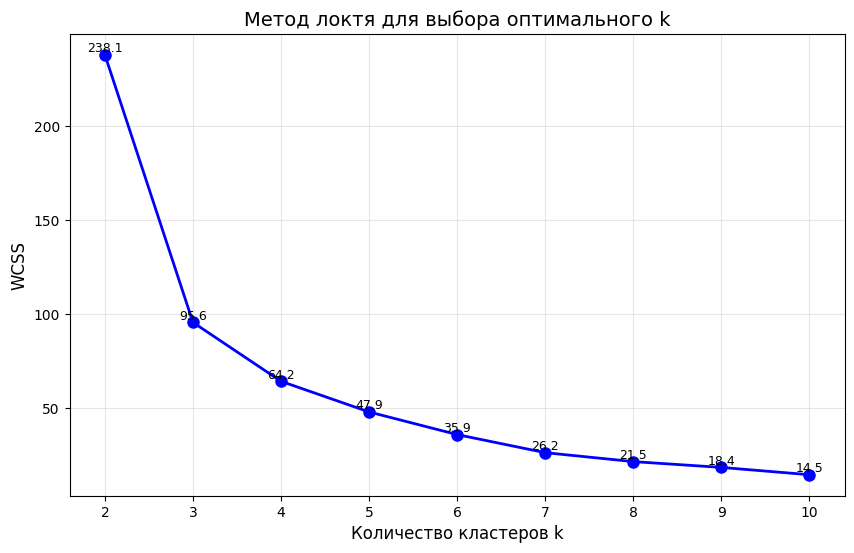

In [1269]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров k', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.title('Метод локтя для выбора оптимального k', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

for k, inertia in zip(k_range, inertias):
    plt.text(k, inertia, f'{inertia:.1f}', ha='center', va='bottom', fontsize=9)

plt.show()

In [1271]:
from sklearn.cluster import KMeans

optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

centroids = kmeans.cluster_centers_


centroids_original = scaler.inverse_transform(centroids)
print("\nКоординаты центроидов")
print(centroids_original)


Координаты центроидов
[[  8.82142857  28.01339286]
 [  9.80172414 127.01724138]
 [ 19.28        79.24      ]]


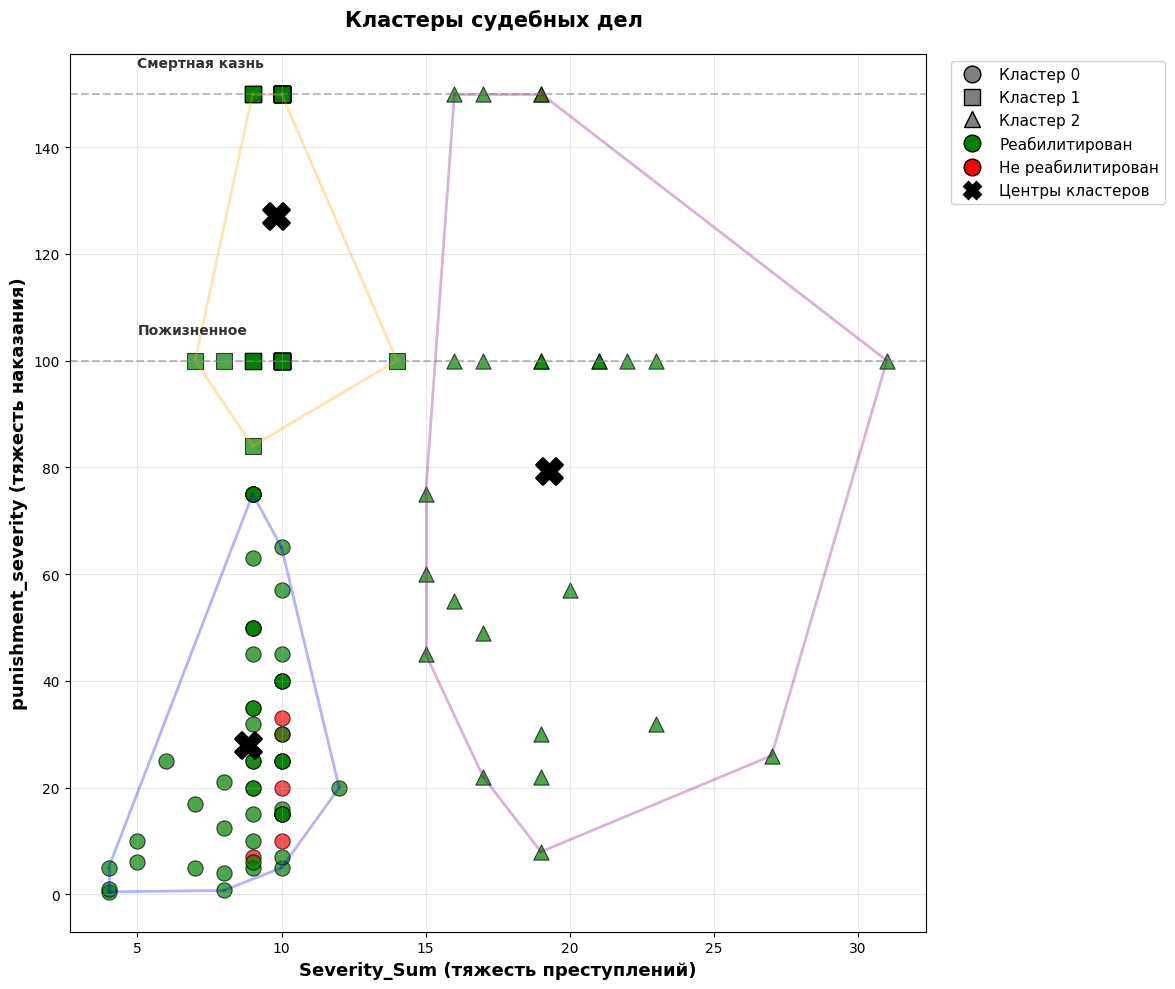

In [1277]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import ConvexHull

plt.figure(figsize=(14, 10))

markers = ['o', 's', '^']  # круг, квадрат, треугольник
rehab_colors = {0: 'red', 1: 'green'}

# Для каждого кластера
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]

    for rehab_status in [0, 1]:
        subset = cluster_data[cluster_data['Legally Exonerated Encoded'] == rehab_status]

        if len(subset) > 0:
            plt.scatter(subset['Severity_Sum'],
                        subset['punishment_severity'],
                        marker=markers[cluster],
                        color=rehab_colors[rehab_status],
                        s=120,
                        alpha=0.7,
                        edgecolors='black',
                        linewidth=0.8,
                        label=f'Кластер {cluster}, {"Реаб." if rehab_status==1 else "Не реаб."}')

plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
           c='black', marker='X', s=350, label='Центры кластеров', zorder=10, linewidth=2)

cluster_line_colors = ['blue', 'orange', 'purple']
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    points = cluster_data[['Severity_Sum', 'punishment_severity']].values

    if len(points) >= 3:
        try:
            hull = ConvexHull(points)
            for simplex in hull.simplices:
                plt.plot(points[simplex, 0], points[simplex, 1],
                        cluster_line_colors[cluster], alpha=0.3, linewidth=2)
        except:
            pass

plt.xlabel('Severity_Sum (тяжесть преступлений)', fontsize=13, fontweight='bold')
plt.ylabel('punishment_severity (тяжесть наказания)', fontsize=13, fontweight='bold')
plt.title('Кластеры судебных дел ',
          fontsize=15, fontweight='bold', pad=20)

plt.axhline(y=100, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
plt.text(5, 105, 'Пожизненное', fontsize=10, alpha=0.8, fontweight='bold')
plt.axhline(y=150, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
plt.text(5, 155, 'Смертная казнь', fontsize=10, alpha=0.8, fontweight='bold')

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=12, label='Кластер 0', markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
           markersize=12, label='Кластер 1', markeredgecolor='black'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray',
           markersize=12, label='Кластер 2', markeredgecolor='black'),

    Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
           markersize=12, label='Реабилитирован', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=12, label='Не реабилитирован', markeredgecolor='black'),

    # Центроиды
    Line2D([0], [0], marker='X', color='black', markersize=12,
           label='Центры кластеров', linestyle='None', markeredgewidth=2),
]

plt.legend(handles=legend_elements, loc='upper left',
           bbox_to_anchor=(1.02, 1), fontsize=11, framealpha=0.9)

plt.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0, 0.85, 1])



plt.show()
